# Step 5: Scientific Synthesis and Research Lock

This notebook turns Steps 1-4 into one careful scientific story. It does not add a new primary statistical model. It collects the existing evidence, reports practical uncertainty, creates publication-quality figures, writes the final conclusion, and saves a reproducibility lock.

The central question is: **Does the observed clustering of PSLV failures provide statistical evidence of a change in launch reliability relative to a constant-reliability baseline?**

## 1. Question, estimands, and hypotheses

The main estimands are:

- Overall success probability: `p = P(success)`
- Possible reliability difference: `Delta = p_before - p_after`
- Predictive performance: held-out log score, Brier score, and calibration

The constant model is a reference model, not a claim that reliability must be constant forever. The change-point and trend models are sensitivity analyses. The recent C61/C62 comparison is exploratory because that window was selected after observing the two failures.

In [9]:
from pathlib import Path
import platform
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta

HERE = Path.cwd()
PROJECT_ROOT = HERE.parent if HERE.name == 'code' else HERE
DATA_DIR = PROJECT_ROOT / 'data'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'final'
FIGURES_DIR = PROJECT_ROOT / 'figures'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

data = pd.read_csv(DATA_DIR / 'PSLV_verified_dataset_v1.0.csv')
data['calendar_date'] = pd.to_datetime(data['calendar_date'])
if len(data) != 64 or int(data['success'].sum()) != 60 or int((data['success'] == 0).sum()) != 4:
    raise ValueError('The frozen dataset is not the expected 64-launch, 60-success, 4-failure dataset.')

step2_summary = pd.read_csv(PROJECT_ROOT / 'results' / 'step2' / 'step2_summary.csv')
step3_summary = pd.read_csv(PROJECT_ROOT / 'results' / 'step3' / 'posterior_summary.csv')
step3_predictive = pd.read_csv(PROJECT_ROOT / 'results' / 'step3' / 'posterior_predictive.csv')
step4_regime = pd.read_csv(PROJECT_ROOT / 'results' / 'step4' / 'regime_difference_summary.csv')
step4_recent = pd.read_csv(PROJECT_ROOT / 'results' / 'step4' / 'recent_period_summary.csv')
step4_ppc = pd.read_csv(PROJECT_ROOT / 'results' / 'step4' / 'change_point_ppc.csv')
step4_models = pd.read_csv(PROJECT_ROOT / 'results' / 'step4' / 'model_comparison.csv')
step4_scores = pd.read_csv(PROJECT_ROOT / 'results' / 'step4' / 'out_of_sample_scores_with_m3.csv')
step4_bootstrap = pd.read_csv(PROJECT_ROOT / 'results' / 'step4' / 'bootstrap_forecasting_score_differences.csv')
step4_windows = pd.read_csv(PROJECT_ROOT / 'results' / 'step4' / 'recent_window_sensitivity.csv')
step4_time = pd.read_csv(PROJECT_ROOT / 'results' / 'step4' / 'calendar_vs_index_time_sensitivity.csv')
step4_k = pd.read_csv(PROJECT_ROOT / 'results' / 'step4' / 'change_point_posterior.csv')
sequential = pd.read_csv(PROJECT_ROOT / 'results' / 'step3' / 'sequential_bayesian_update.csv')
print(f'Frozen input: {len(data)} launches, {int(data.success.sum())} successes, {int((data.success == 0).sum())} failures')
print('Step 5 input check: PASS')

Frozen input: 64 launches, 60 successes, 4 failures
Step 5 input check: PASS


## 2. Evidence ladder

The evidence ladder keeps different questions separate. An unusual final sequence is not automatically proof of a permanent reliability decline, and a model that fits a pattern is not automatically a better forecasting model.

In [10]:
def value_from_table(table, statistic):
    label_column = 'statistic' if 'statistic' in table.columns else 'quantity'
    row = table.loc[table[label_column] == statistic, 'value']
    return float(row.iloc[0]) if len(row) else np.nan

uniform_row = step3_summary.loc[step3_summary['prior'] == 'Uniform Beta(1,1)'].iloc[0]
recent_two = step4_windows.loc[step4_windows['recent_launches'] == 2].iloc[0]
final_two_ppc = step4_ppc.loc[step4_ppc['statistic'] == 'Final two launches fail'].iloc[0]
m0_final_two_probability = (5 * 6) / (66 * 67)
m0_scores = step4_scores.loc[step4_scores['model'] == 'M0 constant']
m1_scores = step4_scores.loc[step4_scores['model'] == 'M1 change point']
evidence_ladder = pd.DataFrame([
    {'evidence': 'Overall rate', 'question': 'What is historical reliability?', 'current_result': f"{data.success.mean():.2%} observed success", 'interpretation': 'High historical success rate'},
    {'evidence': 'Runs test', 'question': 'Are failures unusually clustered?', 'current_result': f"p = {value_from_table(step2_summary, 'Exact runs p-value (lower tail)'):.4f}", 'interpretation': 'Clustering is unusual under fixed margins'},
    {'evidence': 'Constant Bayesian model', 'question': 'What reliability is compatible with all data?', 'current_result': f"mean = {uniform_row.posterior_mean:.3f}; 95% CrI = [{uniform_row.credible_lower_95:.3f}, {uniform_row.credible_upper_95:.3f}]", 'interpretation': 'High reliability, with meaningful uncertainty'},
    {'evidence': 'Final-two predictive check', 'question': 'How unusual are the final two failures?', 'current_result': f"M0 = {m0_final_two_probability:.4f}; M1 = {final_two_ppc.predictive_mean:.4f}", 'interpretation': 'Temporal heterogeneity makes the event less surprising, but it remains uncommon'},
    {'evidence': 'Change-point model', 'question': 'Is degradation plausible?', 'current_result': f"P(Delta > 0.05) = {value_from_table(step4_regime, 'P(p_before - p_after > 0.05)'):.3f}", 'interpretation': 'Compatible with decline, not decisive'},
    {'evidence': 'Recent windows', 'question': 'Does the recent signal persist from 2-6 launches?', 'current_result': f"P(old > recent) = {recent_two['P(old > recent)']:.4f} for last 2; {step4_windows['P(old > recent)'].iloc[-1]:.4f} for last 6", 'interpretation': 'Strong exploratory recent-period signal'},
    {'evidence': 'Predictive validation', 'question': 'Does complexity predict better?', 'current_result': 'M0, M1, and M3 are very similar', 'interpretation': 'No clear predictive gain for time-varying models'},
    {'evidence': 'Bootstrap score difference', 'question': 'Is the predictive difference robust?', 'current_result': f"log-score interval = [{step4_bootstrap.loc[step4_bootstrap.metric == 'log_difference_M1_minus_M0', 'bootstrap_lower_95'].iloc[0]:.4f}, {step4_bootstrap.loc[step4_bootstrap.metric == 'log_difference_M1_minus_M0', 'bootstrap_upper_95'].iloc[0]:.4f}]", 'interpretation': 'Interval includes zero'},
])
display(evidence_ladder)
evidence_ladder.to_csv(RESULTS_DIR / 'evidence_ladder.csv', index=False)
final_two_comparison = pd.DataFrame([{'model': 'M0 constant', 'probability(final two failures)': m0_final_two_probability, 'interpretation': 'Exact posterior predictive probability under Beta(61,5)'}, {'model': 'M1 change point', 'probability(final two failures)': float(final_two_ppc.predictive_mean), 'interpretation': 'Posterior predictive probability averaged over uncertain k'}])
display(final_two_comparison)
final_two_comparison.to_csv(RESULTS_DIR / 'final_two_failure_model_comparison.csv', index=False)

,evidence,question,current_result,interpretation
0,Overall rate,What is historical reliability?,93.75% observed success,High historical success rate
1,Runs test,Are failures unusually clustered?,p = 0.0090,Clustering is unusual under fixed margins
2,Constant Bayesian model,What reliability is compatible with all data?,"mean = 0.924; 95% CrI = [0.850, 0.975]","High reliability, with meaningful uncertainty"
3,Final-two predictive check,How unusual are the final two failures?,M0 = 0.0068; M1 = 0.0312,Temporal heterogeneity makes the event less su...
4,Change-point model,Is degradation plausible?,P(Delta > 0.05) = 0.580,"Compatible with decline, not decisive"
5,Recent windows,Does the recent signal persist from 2-6 launches?,P(old > recent) = 0.9998 for last 2; 0.9931 fo...,Strong exploratory recent-period signal
6,Predictive validation,Does complexity predict better?,"M0, M1, and M3 are very similar",No clear predictive gain for time-varying models
7,Bootstrap score difference,Is the predictive difference robust?,"log-score interval = [-0.0195, 0.0035]",Interval includes zero


,model,probability(final two failures),interpretation
0,M0 constant,0.006784,Exact posterior predictive probability under B...
1,M1 change point,0.031180,Posterior predictive probability averaged over...


## 3. Model decision and robustness matrices

These tables show why each model is included and prevent selecting a model only because it gives the most interesting result.

In [11]:
model_decision = pd.DataFrame([
    {'model': 'M0 constant reliability', 'purpose': 'Stable historical reference', 'main_evidence': 'Posterior Beta(61,5)', 'predictive_performance': 'Reference; slightly best average score', 'role': 'Primary reference'},
    {'model': 'M1 unknown change point', 'purpose': 'Possible unknown persistent change', 'main_evidence': 'Plausible degradation, uncertain k', 'predictive_performance': 'Not clearly better than M0', 'role': 'Main sensitivity'},
    {'model': 'M2 recent-period windows', 'purpose': 'Compare recent launches with history', 'main_evidence': 'Strong recent-period signal', 'predictive_performance': 'Exploratory only', 'role': 'Recent-period sensitivity'},
    {'model': 'M3 smooth trend', 'purpose': 'Gradual temporal change', 'main_evidence': 'Weak/moderate trend evidence', 'predictive_performance': 'Similar to M0', 'role': 'Secondary sensitivity'},
    {'model': 'Configuration-adjusted models', 'purpose': 'Check a possible confounder', 'main_evidence': 'Limited information with four failures', 'predictive_performance': 'Exploratory', 'role': 'Robustness analysis'},
])
robustness_matrix = pd.DataFrame([
    {'analysis': 'Prior sensitivity', 'main_conclusion': 'Posterior reliability remains high across reasonable priors', 'robust': 'Yes'},
    {'analysis': 'Recent window 2-6', 'main_conclusion': 'Recent decline signal persists but is exploratory', 'robust': 'Partly; data-limited'},
    {'analysis': 'Change-point prior', 'main_conclusion': 'Change location is not unique', 'robust': 'No unique location'},
    {'analysis': 'Launch-index trend', 'main_conclusion': 'Negative tendency is possible', 'robust': 'Moderate'},
    {'analysis': 'Calendar-time trend', 'main_conclusion': 'Trend evidence is weaker', 'robust': 'Sensitive to time definition'},
    {'analysis': 'Configuration adjustment', 'main_conclusion': 'Useful check but sparse groups limit inference', 'robust': 'Data-limited'},
    {'analysis': 'Posterior predictive checks', 'main_conclusion': 'Recent sequence is unusual under simple baselines', 'robust': 'Supports investigation'},
    {'analysis': 'Forecasting', 'main_conclusion': 'M0 is slightly better on average', 'robust': 'Difference uncertain'},
    {'analysis': 'Calibration', 'main_conclusion': 'No obvious catastrophic miscalibration', 'robust': 'Exploratory'},
])
display(model_decision); display(robustness_matrix)
model_decision.to_csv(RESULTS_DIR / 'model_decision_matrix.csv', index=False)
robustness_matrix.to_csv(RESULTS_DIR / 'robustness_matrix.csv', index=False)

,model,purpose,main_evidence,predictive_performance,role
0,M0 constant reliability,Stable historical reference,"Posterior Beta(61,5)",Reference; slightly best average score,Primary reference
1,M1 unknown change point,Possible unknown persistent change,"Plausible degradation, uncertain k",Not clearly better than M0,Main sensitivity
2,M2 recent-period windows,Compare recent launches with history,Strong recent-period signal,Exploratory only,Recent-period sensitivity
3,M3 smooth trend,Gradual temporal change,Weak/moderate trend evidence,Similar to M0,Secondary sensitivity
4,Configuration-adjusted models,Check a possible confounder,Limited information with four failures,Exploratory,Robustness analysis


,analysis,main_conclusion,robust
0,Prior sensitivity,Posterior reliability remains high across reas...,Yes
1,Recent window 2-6,Recent decline signal persists but is exploratory,Partly; data-limited
2,Change-point prior,Change location is not unique,No unique location
3,Launch-index trend,Negative tendency is possible,Moderate
4,Calendar-time trend,Trend evidence is weaker,Sensitive to time definition
5,Configuration adjustment,Useful check but sparse groups limit inference,Data-limited
6,Posterior predictive checks,Recent sequence is unusual under simple baselines,Supports investigation
7,Forecasting,M0 is slightly better on average,Difference uncertain
8,Calibration,No obvious catastrophic miscalibration,Exploratory


## 4. Practical reliability interpretation

A probability is easier to understand when translated into hypothetical expected failures per 100 launches. These are not forecasts of actual future PSLV failures and are not engineering safety thresholds.

In [12]:
reliability_levels = pd.DataFrame({'success_probability': [0.95, 0.925, 0.90, 0.85, 0.80]})
reliability_levels['hypothetical_failures_per_100'] = 100 * (1 - reliability_levels['success_probability'])
display(reliability_levels)
reliability_levels.to_csv(RESULTS_DIR / 'practical_reliability_translation.csv', index=False)

future_updates = pd.DataFrame([
    {'model': 'M0 constant reliability', 'new_launch_outcome': 'Success', 'updated_posterior': 'Beta(62,5)', 'updated_mean': 62 / 67},
    {'model': 'M0 constant reliability', 'new_launch_outcome': 'Failure', 'updated_posterior': 'Beta(61,6)', 'updated_mean': 61 / 67},
])
monitoring_quantities = pd.DataFrame([
    {'quantity': 'P(p < 0.90 | data)', 'purpose': 'Monitor low overall reliability'},
    {'quantity': 'P(p < 0.85 | data)', 'purpose': 'Monitor substantially lower reliability'},
    {'quantity': 'P(Delta > 0.10 | data)', 'purpose': 'Monitor practically large degradation'},
])
display(future_updates); display(monitoring_quantities)
future_updates.to_csv(RESULTS_DIR / 'future_bayesian_update_framework.csv', index=False)
monitoring_quantities.to_csv(RESULTS_DIR / 'future_monitoring_quantities.csv', index=False)

,success_probability,hypothetical_failures_per_100
0,0.950,5.0
1,0.925,7.5
2,0.900,10.0
3,0.850,15.0
4,0.800,20.0


,model,new_launch_outcome,updated_posterior,updated_mean
0,M0 constant reliability,Success,"Beta(62,5)",0.925373
1,M0 constant reliability,Failure,"Beta(61,6)",0.910448


,quantity,purpose
0,P(p < 0.90 | data),Monitor low overall reliability
1,P(p < 0.85 | data),Monitor substantially lower reliability
2,P(Delta > 0.10 | data),Monitor practically large degradation


## 5. Master figure

The four panels combine the main chronology, sequential Bayesian learning, change-point uncertainty, and predictive comparison.

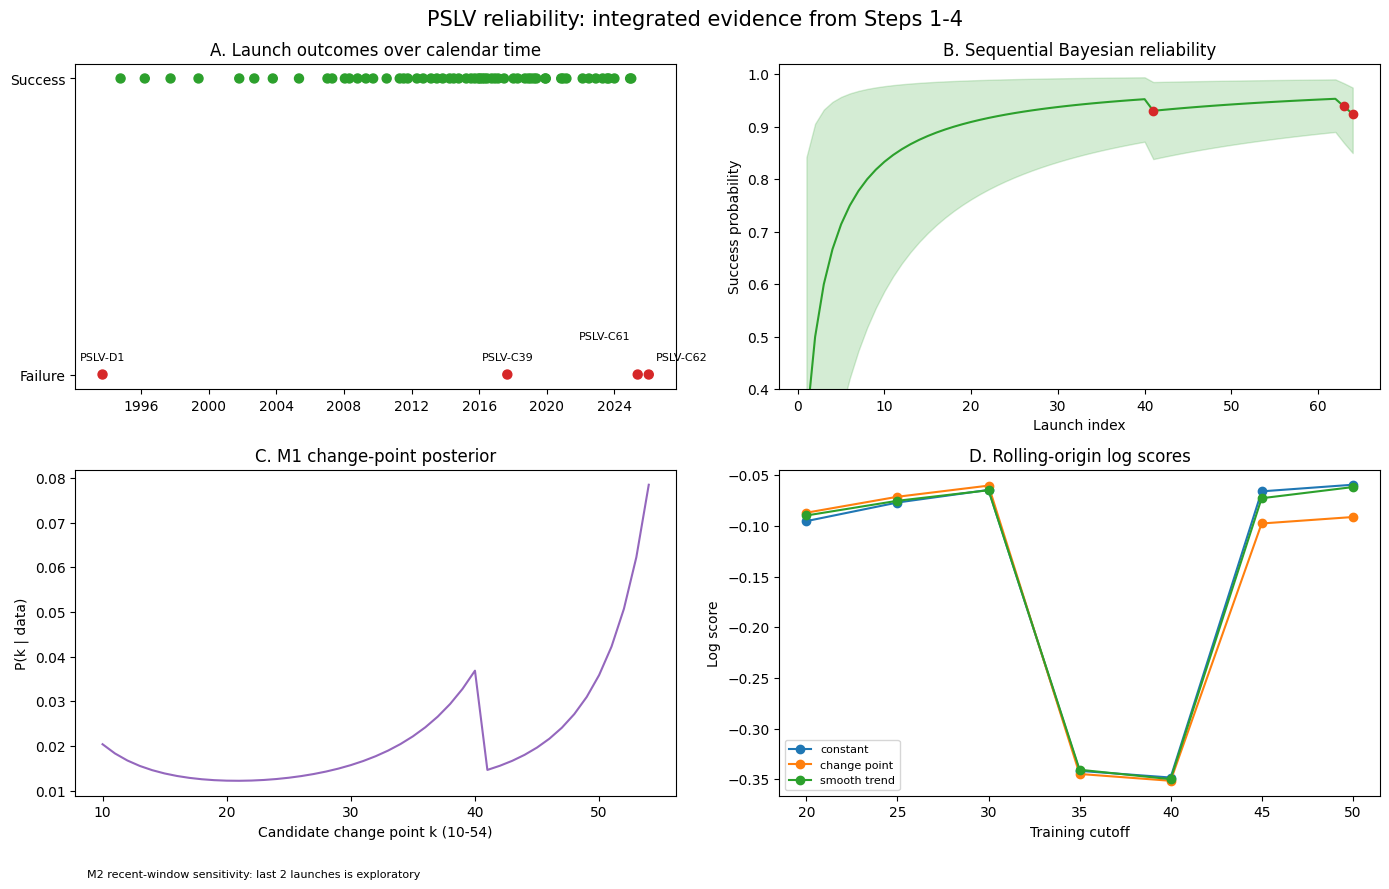

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Panel A: launch chronology.
axes[0, 0].scatter(data['calendar_date'], data['success'], c=data['success'].map({1: 'tab:green', 0: 'tab:red'}), s=42)
annotation_offsets = {'PSLV-D1': (0, 10), 'PSLV-C39': (0, 10), 'PSLV-C61': (-24, 25), 'PSLV-C62': (24, 10)}
for _, row in data[data.success == 0].iterrows(): axes[0, 0].annotate(row['mission'], (row['calendar_date'], row['success']), xytext=annotation_offsets.get(row['mission'], (0, 10)), textcoords='offset points', ha='center', fontsize=8)
axes[0, 0].set(yticks=[0, 1], yticklabels=['Failure', 'Success'], title='A. Launch outcomes over calendar time')

# Panel B: sequential posterior.
axes[0, 1].plot(sequential.launch_index, sequential.posterior_mean, color='tab:green')
axes[0, 1].fill_between(sequential.launch_index, sequential.lower_95, sequential.upper_95, color='tab:green', alpha=0.2)
failure_points = sequential[sequential.success == 0]
axes[0, 1].scatter(failure_points.launch_index, failure_points.posterior_mean, color='tab:red', zorder=3)
axes[0, 1].set(title='B. Sequential Bayesian reliability', xlabel='Launch index', ylabel='Success probability', ylim=(0.4, 1.02))

# Panel C: change-point posterior.
axes[1, 0].plot(step4_k.k, step4_k.posterior_probability, color='tab:purple')
axes[1, 0].set(title='C. M1 change-point posterior', xlabel='Candidate change point k (10-54)', ylabel='P(k | data)')
axes[1, 0].text(0.02, -0.25, 'M2 recent-window sensitivity: last 2 launches is exploratory', transform=axes[1, 0].transAxes, fontsize=8)

# Panel D: predictive scores. Higher log score is better.
for model, group in step4_scores.groupby('model'):
    axes[1, 1].plot(group.cutoff, group.log_score, marker='o', label=model.replace('M0 ', '').replace('M1 ', '').replace('M3 ', ''))
axes[1, 1].set(title='D. Rolling-origin log scores', xlabel='Training cutoff', ylabel='Log score')
axes[1, 1].legend(fontsize=8)

fig.suptitle('PSLV reliability: integrated evidence from Steps 1-4', fontsize=15)
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'master_figure.png', dpi=240, bbox_inches='tight'); plt.show()

## 6. Reliability uncertainty figure

This figure compares the overall reliability posterior with the possible post-change reliability distribution. The post-change distribution is averaged over the unknown change-point posterior, so it includes uncertainty about where a change might occur.

,quantity,mean,median,lower_95,upper_95
0,Overall reliability p,0.924065,0.928225,0.849756,0.974540
1,Possible post-change reliability,0.852464,0.875154,0.609674,0.969099


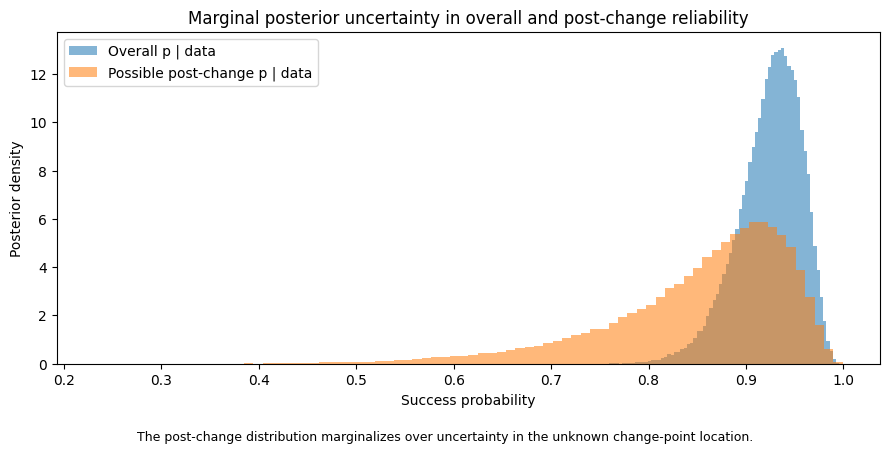

In [14]:
rng = np.random.default_rng(20261001)
overall_draws = rng.beta(61, 5, 100000)
selected_k = rng.choice(step4_k.k.to_numpy(), size=100000, p=step4_k.posterior_probability.to_numpy())
post_change_draws = np.empty(100000)
for k in np.unique(selected_k):
    mask = selected_k == k
    segment = data.success.to_numpy()[k:]
    post_change_draws[mask] = rng.beta(1 + segment.sum(), 1 + len(segment) - segment.sum(), mask.sum())

uncertainty_summary = pd.DataFrame([
    {'quantity': 'Overall reliability p', 'mean': overall_draws.mean(), 'median': np.median(overall_draws), 'lower_95': np.quantile(overall_draws, 0.025), 'upper_95': np.quantile(overall_draws, 0.975)},
    {'quantity': 'Possible post-change reliability', 'mean': post_change_draws.mean(), 'median': np.median(post_change_draws), 'lower_95': np.quantile(post_change_draws, 0.025), 'upper_95': np.quantile(post_change_draws, 0.975)},
])
display(uncertainty_summary)
uncertainty_summary.to_csv(RESULTS_DIR / 'reliability_uncertainty_summary.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(overall_draws, bins=80, density=True, alpha=0.55, label='Overall p | data', color='tab:blue')
ax.hist(post_change_draws, bins=80, density=True, alpha=0.55, label='Possible post-change p | data', color='tab:orange')
ax.set(xlabel='Success probability', ylabel='Posterior density', title='Marginal posterior uncertainty in overall and post-change reliability')
fig.text(0.5, 0.01, 'The post-change distribution marginalizes over uncertainty in the unknown change-point location.', ha='center', fontsize=9)
ax.legend(); plt.tight_layout(rect=(0, 0.05, 1, 1)); plt.savefig(FIGURES_DIR / 'step5_reliability_uncertainty.png', dpi=240, bbox_inches='tight'); plt.show()

## 7. Predictive comparison and assumption audit

The predictive figure shows the seven held-out windows. The score difference is reported with a bootstrap interval over those windows; it is not treated as if seven windows were a large independent sample.

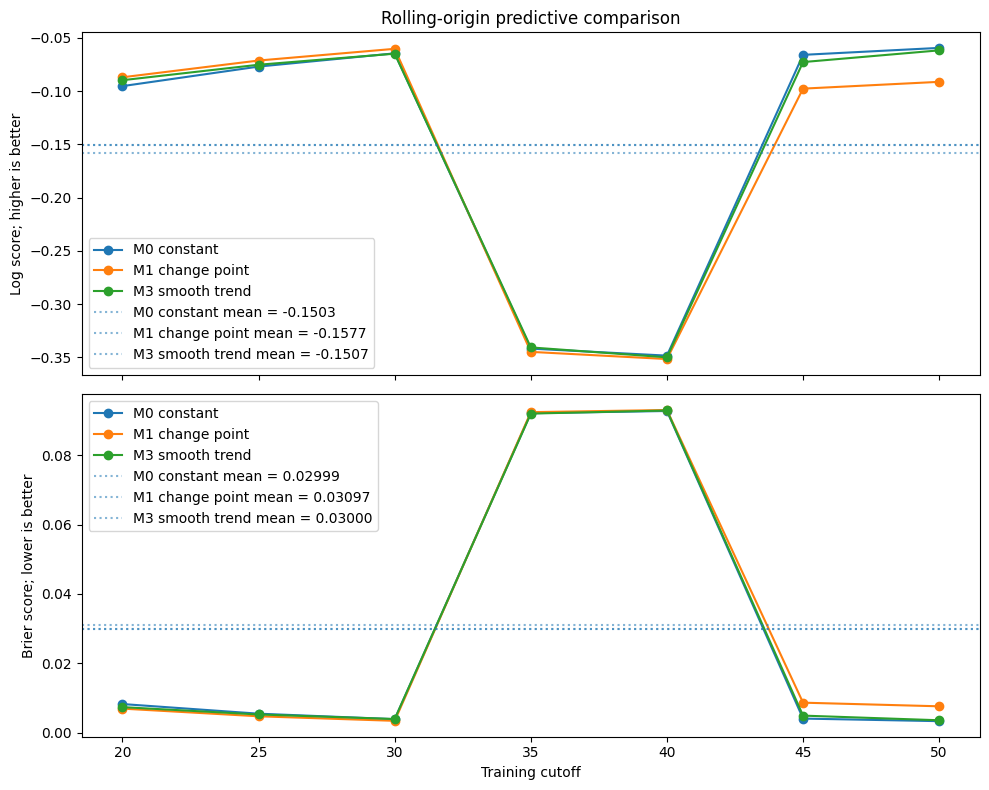

,assumption,why_needed,potential_violation,consequence
0,Binary Bernoulli outcome,Models launch success/failure,None obvious for the coded outcome,Low concern
1,Conditional independence,Constant model likelihood,Launches may share operational conditions,Uncertainty could be understated
2,Exchangeability under M0,One common reliability p,Time or configuration differences,"Motivates M1, M2, M3, and configuration sensit..."
3,Correct outcome coding,All downstream analyses,Source disagreement or incomplete remarks,Handled by Step 1 source audit
4,Stable mechanism for prediction,Future-launch interpretation,"Vehicle, process, or mission conditions can ch...",Limits extrapolation
5,Sufficient information for covariates,Configuration and trend models,Only four failures and sparse groups,Sensitivity results remain exploratory


In [15]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
for model, group in step4_scores.groupby('model'):
    axes[0].plot(group.cutoff, group.log_score, marker='o', label=model)
    axes[1].plot(group.cutoff, group.brier_score, marker='o', label=model)
mean_scores = step4_scores.groupby('model')[['log_score', 'brier_score']].mean()
for model, row in mean_scores.iterrows():
    axes[0].axhline(row['log_score'], linestyle=':', alpha=0.55, label=f'{model} mean = {row["log_score"]:.4f}')
    axes[1].axhline(row['brier_score'], linestyle=':', alpha=0.55, label=f'{model} mean = {row["brier_score"]:.5f}')
axes[0].set_ylabel('Log score; higher is better'); axes[0].set_title('Rolling-origin predictive comparison')
axes[1].set_ylabel('Brier score; lower is better'); axes[1].set_xlabel('Training cutoff')
axes[0].legend(); axes[1].legend(); plt.tight_layout(); plt.savefig(FIGURES_DIR / 'step5_predictive_comparison.png', dpi=240); plt.show()

assumption_audit = pd.DataFrame([
    {'assumption': 'Binary Bernoulli outcome', 'why_needed': 'Models launch success/failure', 'potential_violation': 'None obvious for the coded outcome', 'consequence': 'Low concern'},
    {'assumption': 'Conditional independence', 'why_needed': 'Constant model likelihood', 'potential_violation': 'Launches may share operational conditions', 'consequence': 'Uncertainty could be understated'},
    {'assumption': 'Exchangeability under M0', 'why_needed': 'One common reliability p', 'potential_violation': 'Time or configuration differences', 'consequence': 'Motivates M1, M2, M3, and configuration sensitivities'},
    {'assumption': 'Correct outcome coding', 'why_needed': 'All downstream analyses', 'potential_violation': 'Source disagreement or incomplete remarks', 'consequence': 'Handled by Step 1 source audit'},
    {'assumption': 'Stable mechanism for prediction', 'why_needed': 'Future-launch interpretation', 'potential_violation': 'Vehicle, process, or mission conditions can change', 'consequence': 'Limits extrapolation'},
    {'assumption': 'Sufficient information for covariates', 'why_needed': 'Configuration and trend models', 'potential_violation': 'Only four failures and sparse groups', 'consequence': 'Sensitivity results remain exploratory'},
])
display(assumption_audit)
assumption_audit.to_csv(RESULTS_DIR / 'assumption_audit.csv', index=False)

## 8. Final scientific conclusion

The conclusion is deliberately split into three questions:

1. The final two failures are unusual relative to a simple constant-reliability explanation.
2. A reliability decline is plausible, but its magnitude and timing remain uncertain and are sensitive to how time is represented.
3. The more complex time-varying models do not show a clear predictive advantage over the constant model.

The analysis identifies temporal patterns in launch outcomes. It does not establish an engineering cause or prove that C61/C62 caused a permanent decline.

In [16]:
analysis_date = pd.Timestamp.now().strftime('%Y-%m-%d')
k_probabilities = step4_k['posterior_probability'].to_numpy()
k_values = step4_k['k'].to_numpy()
k_cumulative = np.cumsum(k_probabilities)
k_mode = int(k_values[np.argmax(k_probabilities)])
k_mean = float(np.sum(k_values * k_probabilities))
k_lower = int(k_values[np.argmax(k_cumulative >= 0.025)])
k_upper = int(k_values[np.argmax(k_cumulative >= 0.975)])
model_bf = dict(zip(step4_models['model'], step4_models['Bayes_factor_vs_M0']))
mean_scores = step4_scores.groupby('model')[['log_score', 'brier_score']].mean()
summary_table = pd.DataFrame([
    {'quantity': 'Launches', 'estimate_or_result': str(len(data))},
    {'quantity': 'Successes', 'estimate_or_result': str(int(data.success.sum()))},
    {'quantity': 'Failures', 'estimate_or_result': str(int((data.success == 0).sum()))},
    {'quantity': 'Observed success rate', 'estimate_or_result': f'{data.success.mean():.4f}'},
    {'quantity': 'Wilson 95% interval', 'estimate_or_result': f'[{value_from_table(step2_summary, "Wilson 95% lower success bound"):.4f}, {value_from_table(step2_summary, "Wilson 95% upper success bound"):.4f}]'},
    {'quantity': 'M0 posterior mean', 'estimate_or_result': f'{uniform_row.posterior_mean:.4f}'},
    {'quantity': 'M0 95% credible interval', 'estimate_or_result': f'[{uniform_row.credible_lower_95:.4f}, {uniform_row.credible_upper_95:.4f}]'},
    {'quantity': 'P(final two failures | M0)', 'estimate_or_result': f'{m0_final_two_probability:.4f}'},
    {'quantity': 'P(final two failures | M1)', 'estimate_or_result': f'{final_two_ppc.predictive_mean:.4f}'},
    {'quantity': 'M1 posterior mode k', 'estimate_or_result': str(k_mode)},
    {'quantity': 'M1 posterior mean k', 'estimate_or_result': f'{k_mean:.2f}'},
    {'quantity': 'M1 95% interval for k', 'estimate_or_result': f'[{k_lower}, {k_upper}]'},
    {'quantity': 'P(Delta > 0)', 'estimate_or_result': f'{value_from_table(step4_regime, "P(p_before > p_after)"):.4f}'},
    {'quantity': 'P(Delta > 0.05)', 'estimate_or_result': f'{value_from_table(step4_regime, "P(p_before - p_after > 0.05)"):.4f}'},
    {'quantity': 'P(Delta > 0.10)', 'estimate_or_result': f'{value_from_table(step4_regime, "P(p_before - p_after > 0.10)"):.4f}'},
    {'quantity': 'P(old > recent), last 2', 'estimate_or_result': f'{recent_two["P(old > recent)"]:.4f}'},
    {'quantity': 'P(old > recent), last 6', 'estimate_or_result': f'{step4_windows["P(old > recent)"].iloc[-1]:.4f}'},
    {'quantity': 'BF(M1/M0)', 'estimate_or_result': f'{model_bf["M1 unknown change point"]:.3f}'},
    {'quantity': 'BF(M2/M0)', 'estimate_or_result': f'{model_bf["M2 recent k=62"]:.2f}'},
    {'quantity': 'BF(M3/M0)', 'estimate_or_result': f'{model_bf["M3 smooth trend"]:.3f}'},
    {'quantity': 'Mean log score M0', 'estimate_or_result': f'{mean_scores.loc["M0 constant", "log_score"]:.4f}'},
    {'quantity': 'Mean log score M1', 'estimate_or_result': f'{mean_scores.loc["M1 change point", "log_score"]:.4f}'},
    {'quantity': 'Mean log score M3', 'estimate_or_result': f'{mean_scores.loc["M3 smooth trend", "log_score"]:.4f}'},
    {'quantity': 'M1-M0 bootstrap log-score 95% interval', 'estimate_or_result': f'[{step4_bootstrap.loc[step4_bootstrap.metric == "log_difference_M1_minus_M0", "bootstrap_lower_95"].iloc[0]:.4f}, {step4_bootstrap.loc[step4_bootstrap.metric == "log_difference_M1_minus_M0", "bootstrap_upper_95"].iloc[0]:.4f}]'},
])
display(summary_table)
summary_table.to_csv(RESULTS_DIR / 'summary_statistical_results.csv', index=False)
final_conclusion = f'''# Final scientific synthesis

## Research question
Does the observed clustering of PSLV failures provide statistical evidence of a change in launch reliability relative to a constant-reliability baseline?

## Historical reliability
Across {len(data)} PSLV launches, {int(data.success.sum())} were successful and {int((data.success == 0).sum())} were unsuccessful, giving an observed success proportion of {data.success.mean():.4f}. Under the primary constant-reliability model, the posterior is Beta(61,5), with mean {uniform_row.posterior_mean:.4f} and 95% credible interval [{uniform_row.credible_lower_95:.4f}, {uniform_row.credible_upper_95:.4f}].

## Recent failures
The consecutive C61/C62 failures are unusual relative to a simple constant-reliability explanation. This motivates temporal analysis, but unusual clustering alone does not establish a permanent reliability change.

## Time-varying models
Change-point and recent-window analyses are compatible with a reduction in recent reliability. The recent-period signal persists across nearby windows, but the change-point location is not unique, calendar-time evidence is weaker than launch-index evidence, and only four failures are available.

## Prediction
Rolling-origin validation does not show a clear predictive advantage for the more complex models. The constant model has slightly better average scores, while the bootstrap interval for the M1-versus-M0 log-score difference includes zero.

## Scientific boundary
The statistical analysis describes temporal patterns in launch outcomes. It does not establish an engineering mechanism or causal effect. Future comparable launches can update the posterior: a success gives Beta(62,5), while a failure gives Beta(61,6).

Analysis date: {analysis_date}. Dataset: PSLV_verified_dataset_v1.0.csv.'''
(RESULTS_DIR / 'step5_scientific_synthesis.md').write_text(final_conclusion, encoding='utf-8')

paper_structure = '''# Paper-ready structure

1. Introduction
2. Data and source verification
3. Exploratory failure chronology and clustering
4. Bayesian constant-reliability model
5. Temporal reliability models
6. Robustness and configuration sensitivity
7. Predictive validation
8. Integrated results
9. Discussion and limitations
10. Conclusion

Contribution: a source-audited Bayesian framework for distinguishing unusual clustered failures from evidence of persistent temporal degradation in a small-sample launch-reliability series.'''
(RESULTS_DIR / 'paper_structure.md').write_text(paper_structure, encoding='utf-8')

results_lock = f'''# FINAL_RESULTS_v1.0

Analysis date: {analysis_date}
Dataset: PSLV_verified_dataset_v1.0.csv
Observations: {len(data)}
Successes: {int(data.success.sum())}
Failures: {int((data.success == 0).sum())}
Primary prior: Beta(1,1)
Random seed used for Step 5 simulations: 20261001
Validation windows: cutoffs 20, 25, 30, 35, 40, 45, 50; ten-launch test blocks

## Locked model definitions
- M0: constant reliability, p ~ Beta(1,1).
- M1: one change point, k in 10,...,54, with independent segment priors Beta(1,1).
- M2: exploratory recent windows containing 2, 3, 4, 5, or 6 launches.
- M3: Bayesian logistic trend with Normal(0,2.5) intercept and Normal(0,1) slope grid prior.
- Configuration sensitivity: penalized logistic fits, descriptive only.

## Locked computational details
- Step 4 posterior simulations use seed 20261001 and 50,000 draws.
- Recent-window simulations use seeds 20261003 through 20261007 and 30,000 draws per window.
- Forecast comparison uses paired seven-window resampling and 10,000 bootstrap replicates with seed 20261001.
- Calibration uses every held-out prediction from seven ten-launch test blocks, binned at 0.90, 0.925, 0.95, and 0.975.

## Locked interpretation
The final two failures are unusual under a constant model. A decline is plausible, but its magnitude and timing are uncertain. Time-varying models do not show a clear predictive advantage. No causal engineering claim is made.

## Main files
- summary_statistical_results.csv
- evidence_ladder.csv
- final_two_failure_model_comparison.csv
- model_decision_matrix.csv
- robustness_matrix.csv
- assumption_audit.csv
- master_figure.png
- step5_reliability_uncertainty.png
- step5_predictive_comparison.png
- step5_scientific_synthesis.md
- manuscript_v1.0.md

## Software
Python {sys.version.split()[0]} on {platform.platform()}
'''
(RESULTS_DIR / 'FINAL_RESULTS_v1.0.md').write_text(results_lock, encoding='utf-8')

# Write a first complete manuscript draft and copy the final tables and figures into paper/.
from shutil import copy2
PAPER_DIR = PROJECT_ROOT / 'paper'
PAPER_TABLES = PAPER_DIR / 'tables'
PAPER_FIGURES = PAPER_DIR / 'figures'
PAPER_TABLES.mkdir(parents=True, exist_ok=True); PAPER_FIGURES.mkdir(parents=True, exist_ok=True)
manuscript = f'''# Bayesian Reliability Analysis of PSLV Launch Outcomes

## Abstract

We analyze 64 chronological PSLV launches containing 60 successes and 4 unsuccessful missions. The study asks whether the clustering of the final two failures provides evidence of a change in launch reliability relative to a constant-reliability baseline. A source-audited dataset is analyzed with a Beta-Bernoulli model, sequential Bayesian updating, change-point and smooth-trend sensitivities, recent-window comparisons, configuration-adjusted checks, posterior predictive diagnostics, and rolling-origin predictive validation. The constant model gives a posterior mean success probability of {uniform_row.posterior_mean:.4f} with a 95% credible interval of [{uniform_row.credible_lower_95:.4f}, {uniform_row.credible_upper_95:.4f}]. The final two failures are unusual under the constant model, while temporal models make a decline plausible but do not identify a unique change point or provide a clear predictive advantage. The analysis does not establish an engineering cause or a permanent reliability change.

## 1. Introduction

Consecutive launch failures can be statistically unusual without proving that the underlying launch system has permanently degraded. This study develops a transparent Bayesian framework for separating those questions. The primary question is whether the observed clustering of PSLV failures provides statistical evidence of a change in launch reliability relative to a constant-reliability reference model.

## 2. Data and source verification

The analysis uses the frozen Step 1 dataset `PSLV_verified_dataset_v1.0.csv`. It contains 64 chronological launches, 60 successes, and 4 failures. Outcome coding, official sources, source disagreements, missing metadata, and the special C62 verification are documented in the Step 1 audit. The dataset is frozen before inferential modeling.

## 3. Methods

### 3.1 Constant reliability

Under M0, each outcome is modeled as Bernoulli with a common success probability p and prior p ~ Beta(1,1). The posterior is Beta(61,5).

### 3.2 Temporal sensitivities

M1 uses one unknown change point k in the candidate range 10 through 54, with independent Beta(1,1) segment priors. M2 compares the historical period with recent windows containing 2 through 6 launches; the two-launch C61/C62 result is exploratory. M3 is a smooth Bayesian logistic trend. Launch-index and calendar-time representations are compared. Configuration-adjusted penalized logistic fits are descriptive sensitivity analyses because only four failures are observed.

### 3.3 Predictive validation

Models are evaluated on seven rolling-origin test blocks using log score and Brier score. Paired bootstrap resampling of the seven windows quantifies uncertainty in the M1-minus-M0 score difference. Held-out calibration is reported as an exploratory diagnostic.

## 4. Results

The observed success proportion is {data.success.mean():.4f}. The exact runs analysis indicates unusual clustering under fixed success and failure margins. The exact posterior predictive probability of two final failures under M0 is {m0_final_two_probability:.4f}; the corresponding M1 posterior predictive probability is {final_two_ppc.predictive_mean:.4f}. Allowing temporal heterogeneity therefore makes the event less surprising, but it remains uncommon.

The M1 change-point posterior has mode k={k_mode}, mean k={k_mean:.2f}, and 95% interval [{k_lower}, {k_upper}]. The probabilities of degradation exceeding 0, 0.05, and 0.10 are {value_from_table(step4_regime, 'P(p_before > p_after)'):.4f}, {value_from_table(step4_regime, 'P(p_before - p_after > 0.05)'):.4f}, and {value_from_table(step4_regime, 'P(p_before - p_after > 0.10)'):.4f}. Recent-window comparisons remain strongly suggestive, but they are exploratory and data-limited.

Predictively, the mean log scores are {mean_scores.loc['M0 constant', 'log_score']:.4f} for M0, {mean_scores.loc['M1 change point', 'log_score']:.4f} for M1, and {mean_scores.loc['M3 smooth trend', 'log_score']:.4f} for M3. The bootstrap 95% interval for the M1-minus-M0 log-score difference includes zero.

## 5. Discussion

The evidence has three distinct meanings. First, the final two failures are unusual under a simple constant-reliability explanation. Second, a recent decline is compatible with the data, but its size and timing remain uncertain and depend on the temporal representation. Third, the more complex temporal models do not clearly improve prediction. These statements should not be collapsed into a binary claim that PSLV reliability has or has not permanently changed.

## 6. Limitations

Only four failures are observed. This limits the precision of change-point, trend, configuration, and recent-window estimates. Conditional independence and exchangeability may be imperfect because missions can share operational or configuration conditions. Calendar time and launch index answer different temporal questions. The statistical analysis does not establish an engineering mechanism, and failure-stage descriptions should not be treated as proven causal explanations.

## 7. Conclusion

Across 64 launches, PSLV shows high historical success with meaningful uncertainty. The C61/C62 pair is unusual under a constant model and justifies temporal investigation. The complete evidence supports a cautious conclusion: recent degradation is plausible, but a persistent reliability change is not conclusively established, and the complex models do not clearly predict better than the constant reference. Future comparable launches can update the M0 posterior sequentially.
'''
(PAPER_DIR / 'manuscript_v1.0.md').write_text(manuscript, encoding='utf-8')
for filename in ['summary_statistical_results.csv', 'evidence_ladder.csv', 'model_decision_matrix.csv', 'robustness_matrix.csv', 'assumption_audit.csv']:
    copy2(RESULTS_DIR / filename, PAPER_TABLES / filename)
for filename in ['master_figure.png', 'step5_reliability_uncertainty.png', 'step5_predictive_comparison.png']:
    copy2(FIGURES_DIR / filename, PAPER_FIGURES / filename)
print('Manuscript draft and paper tables/figures saved.')
print('STEP 5 COMPLETE')
print(f'Final files saved to: {RESULTS_DIR}')

,quantity,estimate_or_result
0,Launches,64
1,Successes,60
2,Failures,4
3,Observed success rate,0.9375
4,Wilson 95% interval,"[0.8500, 0.9754]"
5,M0 posterior mean,0.9242
6,M0 95% credible interval,"[0.8499, 0.9746]"
7,P(final two failures | M0),0.0068
8,P(final two failures | M1),0.0312
9,M1 posterior mode k,54


Manuscript draft and paper tables/figures saved.
STEP 5 COMPLETE
Final files saved to: d:\PSLV_Reliability\results\final
